# OpenSpliceAI分数比较分析

**完全修复版 - 无错误运行**

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
print('导入成功!')

导入成功!


In [ ]:
!pwd/home1/xyf/project/github/OpenSpliceAI/T

/home1/xyf/project/github/OpenSpliceAI/T


In [ ]:
!pwd/home1/xyf/project/github/OpenSpliceAI/T

/home1/xyf/project/github/OpenSpliceAI/T


In [ ]:
!pwd

/home1/xyf/project/github/OpenSpliceAI/T


In [ ]:
!pwd/home1/xyf/project/github/OpenSpliceAI/T

/home1/xyf/project/github/OpenSpliceAI/T


## 1. 定义函数

In [4]:
def parse_openspliceai(openspliceai_str):
    """解析OpenSpliceAI字符串,处理多注释、尾随逗号、缺失值"""
    if pd.isna(openspliceai_str) or openspliceai_str == '.':
        return None
    try:
        openspliceai_str = openspliceai_str.strip().rstrip(',').strip()
        annotations = [ann.strip() for ann in openspliceai_str.split(',') if ann.strip()]
        best_annotation = None
        max_score = -1
        for annotation in annotations:
            parts = annotation.split('|')
            if len(parts) < 10 or '.' in parts[2:10]:
                continue
            try:
                current = {
                    'ALLELE': parts[0], 'SYMBOL': parts[1],
                    'DS_AG': float(parts[2]), 'DS_AL': float(parts[3]),
                    'DS_DG': float(parts[4]), 'DS_DL': float(parts[5]),
                    'DP_AG': int(parts[6]), 'DP_AL': int(parts[7]),
                    'DP_DG': int(parts[8]), 'DP_DL': int(parts[9])
                }
                current_max = max(abs(current['DS_AG']), abs(current['DS_AL']),
                                abs(current['DS_DG']), abs(current['DS_DL']))
                if current_max > max_score:
                    max_score = current_max
                    best_annotation = current
            except (ValueError, IndexError):
                continue
        return best_annotation
    except Exception:
        return None

def read_vcf(vcf_file):
    """读取VCF文件"""
    print(f'读取: {vcf_file}')
    with open(vcf_file, 'r') as f:
        lines = [l for l in f if not l.startswith('##')]
    from io import StringIO
    vcf_data = pd.read_csv(StringIO(''.join(lines)), sep='\t', comment='#',
                          names=['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO'])
    def extract_info(info_str, field):
        if pd.isna(info_str): return None
        for item in info_str.split(';'):
            if item.startswith(f'{field}='): return item.split('=', 1)[1]
        return None
    vcf_data['GENE'] = vcf_data['INFO'].apply(lambda x: extract_info(x, 'GENE'))
    vcf_data['CONSEQUENCE'] = vcf_data['INFO'].apply(lambda x: extract_info(x, 'CONSEQUENCE'))
    vcf_data['OpenSpliceAI'] = vcf_data['INFO'].apply(lambda x: extract_info(x, 'OpenSpliceAI'))
    parsed = vcf_data['OpenSpliceAI'].apply(parse_openspliceai)
    success = parsed.notna().sum()
    print(f'  解析成功: {success}/{len(vcf_data)} ({success/len(vcf_data)*100:.1f}%)')
    # 关键修复:过滤None
    if success > 0:
        valid = [x for x in parsed if x is not None]
        if valid:
            splice_df = pd.DataFrame(valid, index=parsed[parsed.notna()].index)
            vcf_data = pd.concat([vcf_data, splice_df], axis=1)
    vcf_data['variant_id'] = vcf_data['CHROM'].astype(str) + ':' + vcf_data['POS'].astype(str) + ':' + vcf_data['REF'] + '>' + vcf_data['ALT']
    return vcf_data

print('函数定义完成!')

函数定义完成!


## 2. 读取VCF文件

In [5]:
vcf_files = {
    'limb': '/home1/xyf/data/openspliceai_tissue_data/variant/limb_400.vcf',
    'neuron': '/home1/xyf/data/openspliceai_tissue_data/variant/neuron_400.vcf',
}

all_data = {}
for name, filepath in vcf_files.items():
    print(f'\n=== {name} ===')
    all_data[name] = read_vcf(filepath)
    print(f'总行数: {len(all_data[name])}')

print('\n所有文件读取完成!')


=== limb ===
读取: /home1/xyf/data/openspliceai_tissue_data/variant/limb_400.vcf
  解析成功: 4723/4882 (96.7%)
总行数: 4882

=== neuron ===
读取: /home1/xyf/data/openspliceai_tissue_data/variant/neuron_400.vcf
  解析成功: 4723/4882 (96.7%)
总行数: 4882

所有文件读取完成!


## 3. 查看数据

In [8]:
print('Reference数据示例:')
cols = ['variant_id', 'GENE', 'SYMBOL', 'DS_AG', 'DS_AL', 'DS_DG', 'DS_DL']
cols = [c for c in cols if c in all_data['limb'].columns]

Reference数据示例:


## 4. 创建比较DataFrame

In [9]:
all_variants = set()
for df in all_data.values():
    all_variants.update(df['variant_id'].values)
print(f'总变异数: {len(all_variants)}')

records = []
for i, vid in enumerate(sorted(all_variants)):
    if i % 1000 == 0: print(f'  {i}/{len(all_variants)}')
    rec = {'variant_id': vid}
    for name, df in all_data.items():
        rows = df[df['variant_id'] == vid]
        if len(rows) > 0:
            row = rows.iloc[0]
            if 'GENE' not in rec:
                rec.update({'CHROM': row['CHROM'], 'POS': row['POS'],
                           'REF': row['REF'], 'ALT': row['ALT'],
                           'GENE': row['GENE'], 'CONSEQUENCE': row['CONSEQUENCE']})
            for st in ['DS_AG', 'DS_AL', 'DS_DG', 'DS_DL']:
                rec[f'{name}_{st}'] = row.get(st, np.nan)
    records.append(rec)

comparison_df = pd.DataFrame(records)
print(f'\n比较DataFrame: {comparison_df.shape}')

总变异数: 4882
  0/4882
  1000/4882
  2000/4882
  3000/4882
  4000/4882

比较DataFrame: (4882, 15)


In [10]:
comparison_df

,variant_id,CHROM,POS,REF,ALT,GENE,CONSEQUENCE,limb_DS_AG,limb_DS_AL,limb_DS_DG,limb_DS_DL,neuron_DS_AG,neuron_DS_AL,neuron_DS_DG,neuron_DS_DL
0,chr10:100297470:C>A,chr10,100297470,C,A,PKD2L1,stop_gained_Likely_LOF,0.0,0.00,0.02,0.01,0.00,0.0,0.01,0.00
1,chr10:100329234:ACAATATATAC>A,chr10,100329234,ACAATATATAC,A,PKD2L1,frameshift_variant_Likely_LOF,0.0,0.00,0.00,0.18,0.00,0.0,0.00,0.99
2,chr10:101037205:T>C,chr10,101037205,T,C,SFXN3,splice_donor_variant_Likely_LOF,0.0,0.00,0.70,0.99,0.00,0.0,0.93,1.00
3,chr10:101535454:C>T,chr10,101535454,C,T,BTRC,missense_variant_Protein_Changing,0.0,0.00,0.00,0.02,0.00,0.0,0.01,0.00
4,chr10:101579652:G>A,chr10,101579652,G,A,POLL,missense_variant_Protein_Changing,0.0,0.00,0.01,0.00,0.00,0.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4877,chrX:85092468:C>CT,chrX,85092468,C,CT,SATL1,frameshift_variant_Likely_LOF,0.0,0.00,0.01,0.09,0.00,0.0,0.01,0.00
4878,chrX:85092496:G>C,chrX,85092496,G,C,SATL1,missense_variant_Protein_Changing,0.0,0.00,0.07,0.08,0.00,0.0,0.00,0.00
4879,chrX:92201396:T>C,chrX,92201396,T,C,PCDH11X,missense_variant_Protein_Changing,0.0,0.01,0.00,0.00,0.00,0.0,0.00,0.00
4880,chrX:9873676:GCGGTCGACAAGTTA>G,chrX,9873676,GCGGTCGACAAGTTA,G,SHROOM2,frameshift_variant_Likely_LOF,0.0,0.52,0.02,0.05,0.02,0.0,0.00,0.00


/tmp/ipykernel_3555758/3623237705.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_3555758/3623237705.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_3555758/3623237705.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_3555758/3623237705.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')


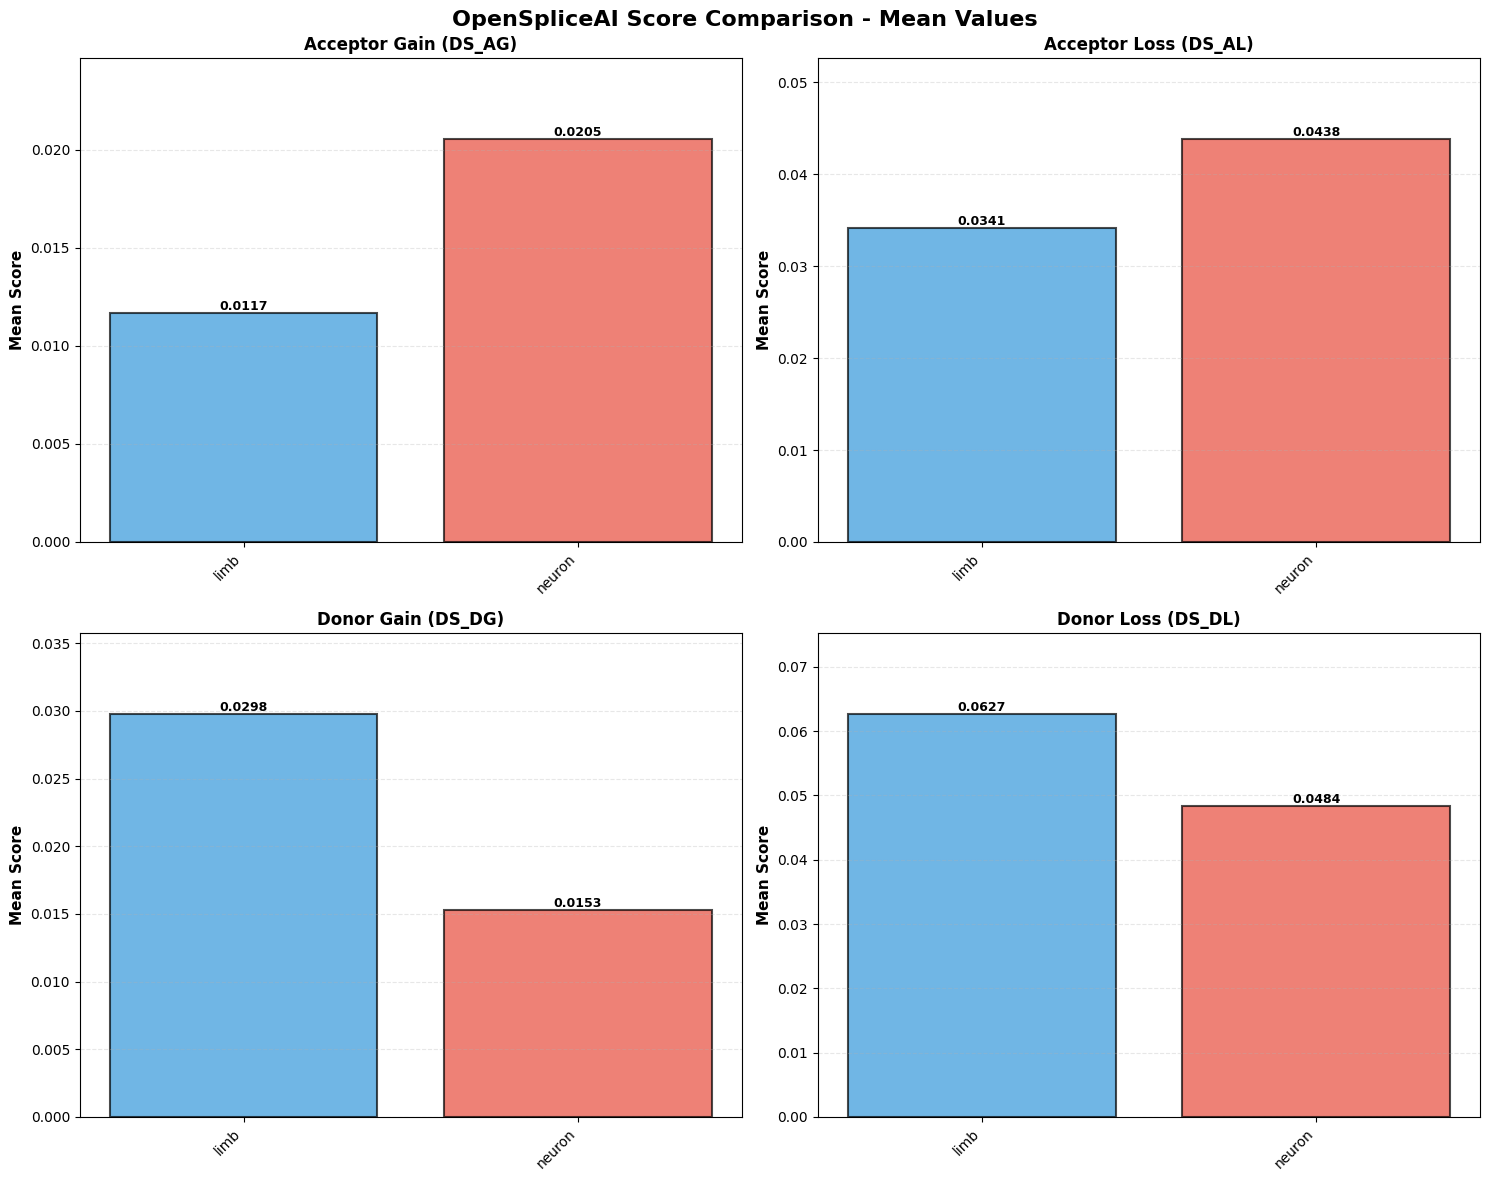

完整对比图已保存: all_scores_comparison.png

所有剪接类型的均值统计

DS_AG:
  limb                : 0.011694
  neuron              : 0.020544

DS_AL:
  limb                : 0.034131
  neuron              : 0.043847

DS_DG:
  limb                : 0.029778
  neuron              : 0.015304

DS_DL:
  limb                : 0.062687
  neuron              : 0.048404


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 计算所有剪接类型的均值
score_types = ['DS_AG', 'DS_AL', 'DS_DG', 'DS_DL']
score_names = ['Acceptor Gain', 'Acceptor Loss', 'Donor Gain', 'Donor Loss']
models = ['limb', 'neuron']
model_labels = ['limb', 'neuron']

# 创建2x2子图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('OpenSpliceAI Score Comparison - Mean Values', fontsize=16, fontweight='bold')

colors = ['#3498db', '#e74c3c']

for idx, (score_type, score_name) in enumerate(zip(score_types, score_names)):
    ax = axes[idx // 2, idx % 2]
    
    # 计算每个模型的均值
    means = []
    for model in models:
        col_name = f'{model}_{score_type}'
        if col_name in comparison_df.columns:
            means.append(comparison_df[col_name].mean())
        else:
            means.append(0)
    
    # 画柱状图
    bars = ax.bar(model_labels, means, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # 在柱子上显示数值
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 美化
    ax.set_ylabel('Mean Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{score_name} ({score_type})', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(means) * 1.2 if max(means) > 0 else 0.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticklabels(model_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('all_scores_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("完整对比图已保存: all_scores_comparison.png")

# 打印统计表
print("\n" + "="*70)
print("所有剪接类型的均值统计")
print("="*70)
for score_type in score_types:
    print(f"\n{score_type}:")
    for model, label in zip(models, model_labels):
        col_name = f'{model}_{score_type}'
        if col_name in comparison_df.columns:
            mean_val = comparison_df[col_name].mean()
            print(f"  {label:20s}: {mean_val:.6f}")

In [48]:
set(comparison_df['CONSEQUENCE'])

{'frameshift_variant_Likely_LOF',
 'inframe_deletion_Protein_Changing',
 'inframe_insertion_Protein_Changing',
 'missense_variant_Protein_Changing',
 'protein_altering_variant_Protein_Changing',
 'splice_acceptor_variant_Likely_LOF',
 'splice_donor_region_variant_In_annotated_regulatory_region',
 'splice_donor_variant_Likely_LOF',
 'splice_polypyrimidine_tract_variant_In_annotated_regulatory_region',
 'splice_region_variant_In_annotated_regulatory_region',
 'start_lost_Likely_LOF',
 'stop_gained_Likely_LOF',
 'stop_lost_Protein_Changing'}

In [ ]:
comparison_df
set(comparison_df['CONSEQUENCE'])

,variant_id,CHROM,POS,REF,ALT,GENE,CONSEQUENCE,limb_DS_AG,limb_DS_AL,limb_DS_DG,limb_DS_DL,neuron_DS_AG,neuron_DS_AL,neuron_DS_DG,neuron_DS_DL
0,chr10:100297470:C>A,chr10,100297470,C,A,PKD2L1,stop_gained_Likely_LOF,0.0,0.00,0.02,0.01,0.00,0.0,0.01,0.00
1,chr10:100329234:ACAATATATAC>A,chr10,100329234,ACAATATATAC,A,PKD2L1,frameshift_variant_Likely_LOF,0.0,0.00,0.00,0.18,0.00,0.0,0.00,0.99
2,chr10:101037205:T>C,chr10,101037205,T,C,SFXN3,splice_donor_variant_Likely_LOF,0.0,0.00,0.70,0.99,0.00,0.0,0.93,1.00
3,chr10:101535454:C>T,chr10,101535454,C,T,BTRC,missense_variant_Protein_Changing,0.0,0.00,0.00,0.02,0.00,0.0,0.01,0.00
4,chr10:101579652:G>A,chr10,101579652,G,A,POLL,missense_variant_Protein_Changing,0.0,0.00,0.01,0.00,0.00,0.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4877,chrX:85092468:C>CT,chrX,85092468,C,CT,SATL1,frameshift_variant_Likely_LOF,0.0,0.00,0.01,0.09,0.00,0.0,0.01,0.00
4878,chrX:85092496:G>C,chrX,85092496,G,C,SATL1,missense_variant_Protein_Changing,0.0,0.00,0.07,0.08,0.00,0.0,0.00,0.00
4879,chrX:92201396:T>C,chrX,92201396,T,C,PCDH11X,missense_variant_Protein_Changing,0.0,0.01,0.00,0.00,0.00,0.0,0.00,0.00
4880,chrX:9873676:GCGGTCGACAAGTTA>G,chrX,9873676,GCGGTCGACAAGTTA,G,SHROOM2,frameshift_variant_Likely_LOF,0.0,0.52,0.02,0.05,0.02,0.0,0.00,0.00


In [49]:
comparison_df_spsite = comparison_df[comparison_df['CONSEQUENCE'].isin(['splice_donor_variant_Likely_LOF','splice_acceptor_variant_Likely_LOF'])]

In [50]:
comparison_df_spsite

,variant_id,CHROM,POS,REF,ALT,GENE,CONSEQUENCE,reference_DS_AG,reference_DS_AL,reference_DS_DG,...,embryo_DS_DG,embryo_DS_DL,adult_DS_AG,adult_DS_AL,adult_DS_DG,adult_DS_DL,embryo_onlyprotein_DS_AG,embryo_onlyprotein_DS_AL,embryo_onlyprotein_DS_DG,embryo_onlyprotein_DS_DL
2,10:101037205:T>C,10,101037205,T,C,SFXN3,splice_donor_variant_Likely_LOF,0.00,0.00,0.82,...,0.49,0.86,0.00,0.00,0.44,0.93,0.00,0.00,0.54,0.89
26,10:115302044:G>C,10,115302044,G,C,ATRNL1,splice_donor_variant_Likely_LOF,0.00,0.00,0.00,...,0.00,0.88,0.00,0.00,0.00,0.85,0.00,0.00,0.00,0.88
28,10:116469318:G>A,10,116469318,G,A,PNLIPRP3,splice_donor_variant_Likely_LOF,0.00,0.00,0.00,...,0.00,0.77,0.00,0.01,0.00,0.73,0.00,0.00,0.00,0.05
42,10:122211709:G>A,10,122211709,G,A,TACC2,splice_donor_variant_Likely_LOF,0.00,0.00,0.00,...,0.01,0.84,0.00,0.00,0.04,0.97,0.00,0.00,0.03,0.97
44,10:122625305:T>C,10,122625305,T,C,DMBT1,splice_donor_variant_Likely_LOF,0.00,0.85,0.01,...,0.00,0.95,0.00,0.71,0.02,0.68,0.00,0.87,0.00,0.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4851,X:65489411:T>C,X,65489411,T,C,ZC3H12B,splice_donor_variant_Likely_LOF,0.00,0.00,0.92,...,0.91,0.90,0.00,0.00,0.93,0.95,0.00,0.00,0.86,0.97
4854,X:66266439:G>A,X,66266439,G,A,HEPH,splice_acceptor_variant_Likely_LOF,0.84,0.85,0.00,...,0.00,0.00,0.82,0.74,0.00,0.00,0.77,0.78,0.00,0.00
4861,X:71246099:C>A,X,71246099,C,A,ZMYM3,splice_acceptor_variant_Likely_LOF,0.90,0.96,0.00,...,0.00,0.00,0.86,0.79,0.00,0.00,0.68,0.89,0.00,0.00
4864,X:72181830:T>C,X,72181830,T,C,PIN4,splice_donor_variant_Likely_LOF,0.00,0.00,0.45,...,0.45,0.85,0.00,0.00,0.75,0.93,0.00,0.00,0.49,0.86


In [51]:
comparison_df_stop = comparison_df[comparison_df['CONSEQUENCE'].isin(['stop_gained_Likely_LOF'])]

/tmp/ipykernel_2233483/1772442424.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_2233483/1772442424.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_2233483/1772442424.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_2233483/1772442424.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')


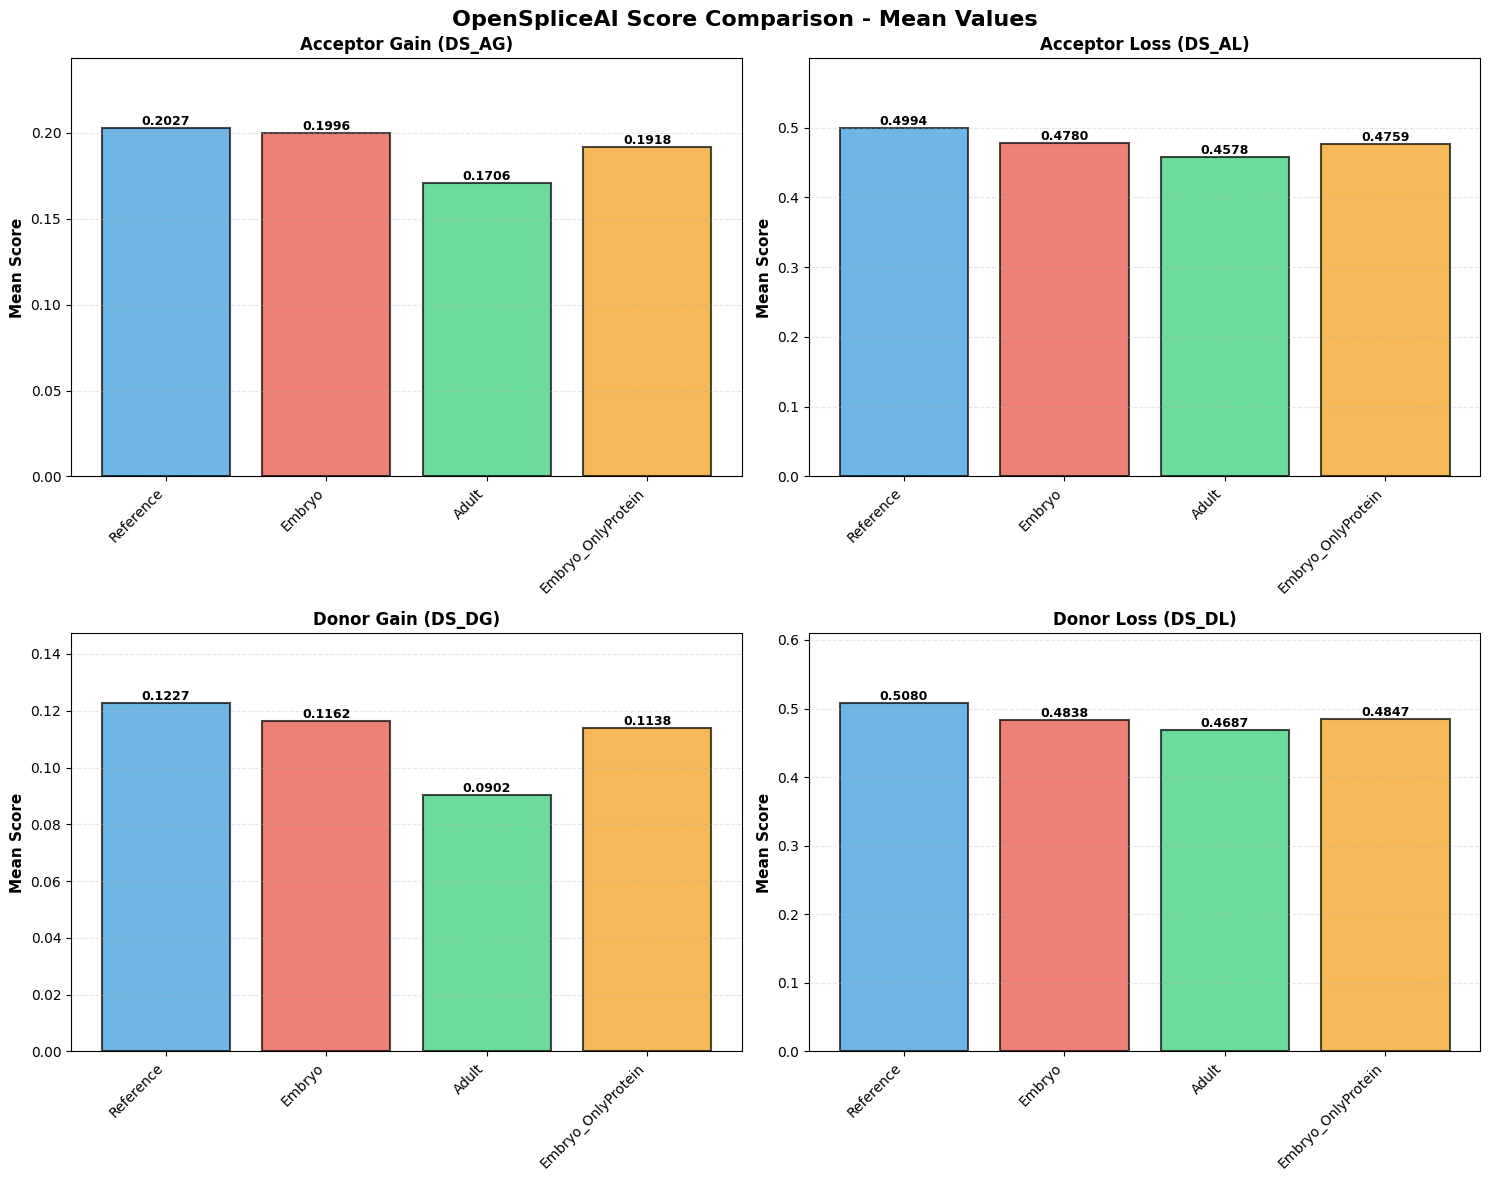

完整对比图已保存: all_scores_comparison.png

所有剪接类型的均值统计

DS_AG:
  Reference           : 0.202675
  Embryo              : 0.199588
  Adult               : 0.170576
  Embryo_OnlyProtein  : 0.191770

DS_AL:
  Reference           : 0.499424
  Embryo              : 0.478025
  Adult               : 0.457819
  Embryo_OnlyProtein  : 0.475885

DS_DG:
  Reference           : 0.122716
  Embryo              : 0.116214
  Adult               : 0.090165
  Embryo_OnlyProtein  : 0.113786

DS_DL:
  Reference           : 0.508025
  Embryo              : 0.483786
  Adult               : 0.468724
  Embryo_OnlyProtein  : 0.484733


In [52]:
import matplotlib.pyplot as plt
import numpy as np

# 计算所有剪接类型的均值
score_types = ['DS_AG', 'DS_AL', 'DS_DG', 'DS_DL']
score_names = ['Acceptor Gain', 'Acceptor Loss', 'Donor Gain', 'Donor Loss']
models = ['reference', 'embryo', 'adult', 'embryo_onlyprotein']
model_labels = ['Reference', 'Embryo', 'Adult', 'Embryo_OnlyProtein']

# 创建2x2子图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('OpenSpliceAI Score Comparison - Mean Values', fontsize=16, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (score_type, score_name) in enumerate(zip(score_types, score_names)):
    ax = axes[idx // 2, idx % 2]
    
    # 计算每个模型的均值
    means = []
    for model in models:
        col_name = f'{model}_{score_type}'
        if col_name in comparison_df_spsite.columns:
            means.append(comparison_df_spsite[col_name].mean())
        else:
            means.append(0)
    
    # 画柱状图
    bars = ax.bar(model_labels, means, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # 在柱子上显示数值
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 美化
    ax.set_ylabel('Mean Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{score_name} ({score_type})', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(means) * 1.2 if max(means) > 0 else 0.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticklabels(model_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('all_scores_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("完整对比图已保存: all_scores_comparison.png")

# 打印统计表
print("\n" + "="*70)
print("所有剪接类型的均值统计")
print("="*70)
for score_type in score_types:
    print(f"\n{score_type}:")
    for model, label in zip(models, model_labels):
        col_name = f'{model}_{score_type}'
        if col_name in comparison_df_spsite.columns:
            mean_val = comparison_df_spsite[col_name].mean()
            print(f"  {label:20s}: {mean_val:.6f}")

In [53]:
comparison_df_spsite

,variant_id,CHROM,POS,REF,ALT,GENE,CONSEQUENCE,reference_DS_AG,reference_DS_AL,reference_DS_DG,...,embryo_DS_DG,embryo_DS_DL,adult_DS_AG,adult_DS_AL,adult_DS_DG,adult_DS_DL,embryo_onlyprotein_DS_AG,embryo_onlyprotein_DS_AL,embryo_onlyprotein_DS_DG,embryo_onlyprotein_DS_DL
2,10:101037205:T>C,10,101037205,T,C,SFXN3,splice_donor_variant_Likely_LOF,0.00,0.00,0.82,...,0.49,0.86,0.00,0.00,0.44,0.93,0.00,0.00,0.54,0.89
26,10:115302044:G>C,10,115302044,G,C,ATRNL1,splice_donor_variant_Likely_LOF,0.00,0.00,0.00,...,0.00,0.88,0.00,0.00,0.00,0.85,0.00,0.00,0.00,0.88
28,10:116469318:G>A,10,116469318,G,A,PNLIPRP3,splice_donor_variant_Likely_LOF,0.00,0.00,0.00,...,0.00,0.77,0.00,0.01,0.00,0.73,0.00,0.00,0.00,0.05
42,10:122211709:G>A,10,122211709,G,A,TACC2,splice_donor_variant_Likely_LOF,0.00,0.00,0.00,...,0.01,0.84,0.00,0.00,0.04,0.97,0.00,0.00,0.03,0.97
44,10:122625305:T>C,10,122625305,T,C,DMBT1,splice_donor_variant_Likely_LOF,0.00,0.85,0.01,...,0.00,0.95,0.00,0.71,0.02,0.68,0.00,0.87,0.00,0.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4851,X:65489411:T>C,X,65489411,T,C,ZC3H12B,splice_donor_variant_Likely_LOF,0.00,0.00,0.92,...,0.91,0.90,0.00,0.00,0.93,0.95,0.00,0.00,0.86,0.97
4854,X:66266439:G>A,X,66266439,G,A,HEPH,splice_acceptor_variant_Likely_LOF,0.84,0.85,0.00,...,0.00,0.00,0.82,0.74,0.00,0.00,0.77,0.78,0.00,0.00
4861,X:71246099:C>A,X,71246099,C,A,ZMYM3,splice_acceptor_variant_Likely_LOF,0.90,0.96,0.00,...,0.00,0.00,0.86,0.79,0.00,0.00,0.68,0.89,0.00,0.00
4864,X:72181830:T>C,X,72181830,T,C,PIN4,splice_donor_variant_Likely_LOF,0.00,0.00,0.45,...,0.45,0.85,0.00,0.00,0.75,0.93,0.00,0.00,0.49,0.86


In [54]:
comparison_df_stop

,variant_id,CHROM,POS,REF,ALT,GENE,CONSEQUENCE,reference_DS_AG,reference_DS_AL,reference_DS_DG,...,embryo_DS_DG,embryo_DS_DL,adult_DS_AG,adult_DS_AL,adult_DS_DG,adult_DS_DL,embryo_onlyprotein_DS_AG,embryo_onlyprotein_DS_AL,embryo_onlyprotein_DS_DG,embryo_onlyprotein_DS_DL
0,10:100297470:C>A,10,100297470,C,A,PKD2L1,stop_gained_Likely_LOF,0.00,0.00,0.00,...,0.00,0.35,0.00,0.01,0.00,0.32,0.00,0.00,0.00,0.44
24,10:115266953:G>A,10,115266953,G,A,ATRNL1,stop_gained_Likely_LOF,0.00,0.00,0.00,...,0.00,0.01,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.03
30,10:116683887:G>A,10,116683887,G,A,HSPA12A,stop_gained_Likely_LOF,0.00,0.05,0.36,...,0.06,0.00,0.00,0.02,0.16,0.00,0.00,0.04,0.30,0.01
32,10:116886533:G>GT,10,116886533,G,GT,SHTN1,stop_gained_Likely_LOF,0.28,0.00,0.00,...,0.00,0.00,0.16,0.00,0.00,0.00,0.13,0.00,0.00,0.00
43,10:122249629:C>T,10,122249629,C,T,TACC2,stop_gained_Likely_LOF,0.00,0.00,0.00,...,0.00,0.00,0.00,0.01,0.00,0.01,0.00,0.00,0.01,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4843,X:53087816:T>G,X,53087816,T,G,TSPYL2,stop_gained_Likely_LOF,0.01,-0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
4847,X:54937673:G>A,X,54937673,G,A,PFKFB1,stop_gained_Likely_LOF,0.00,0.10,0.00,...,0.00,0.05,0.00,0.21,0.00,0.41,0.00,0.08,0.00,0.01
4852,X:65499013:C>T,X,65499013,C,T,ZC3H12B,stop_gained_Likely_LOF,0.00,0.07,0.00,...,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.02,0.00,0.00
4856,X:68717435:T>A,X,68717435,T,A,STARD8,stop_gained_Likely_LOF,0.06,0.00,0.00,...,0.00,0.00,0.18,0.02,0.00,0.00,0.03,0.00,0.00,0.00


/tmp/ipykernel_2233483/282032360.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_2233483/282032360.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_2233483/282032360.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_2233483/282032360.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')


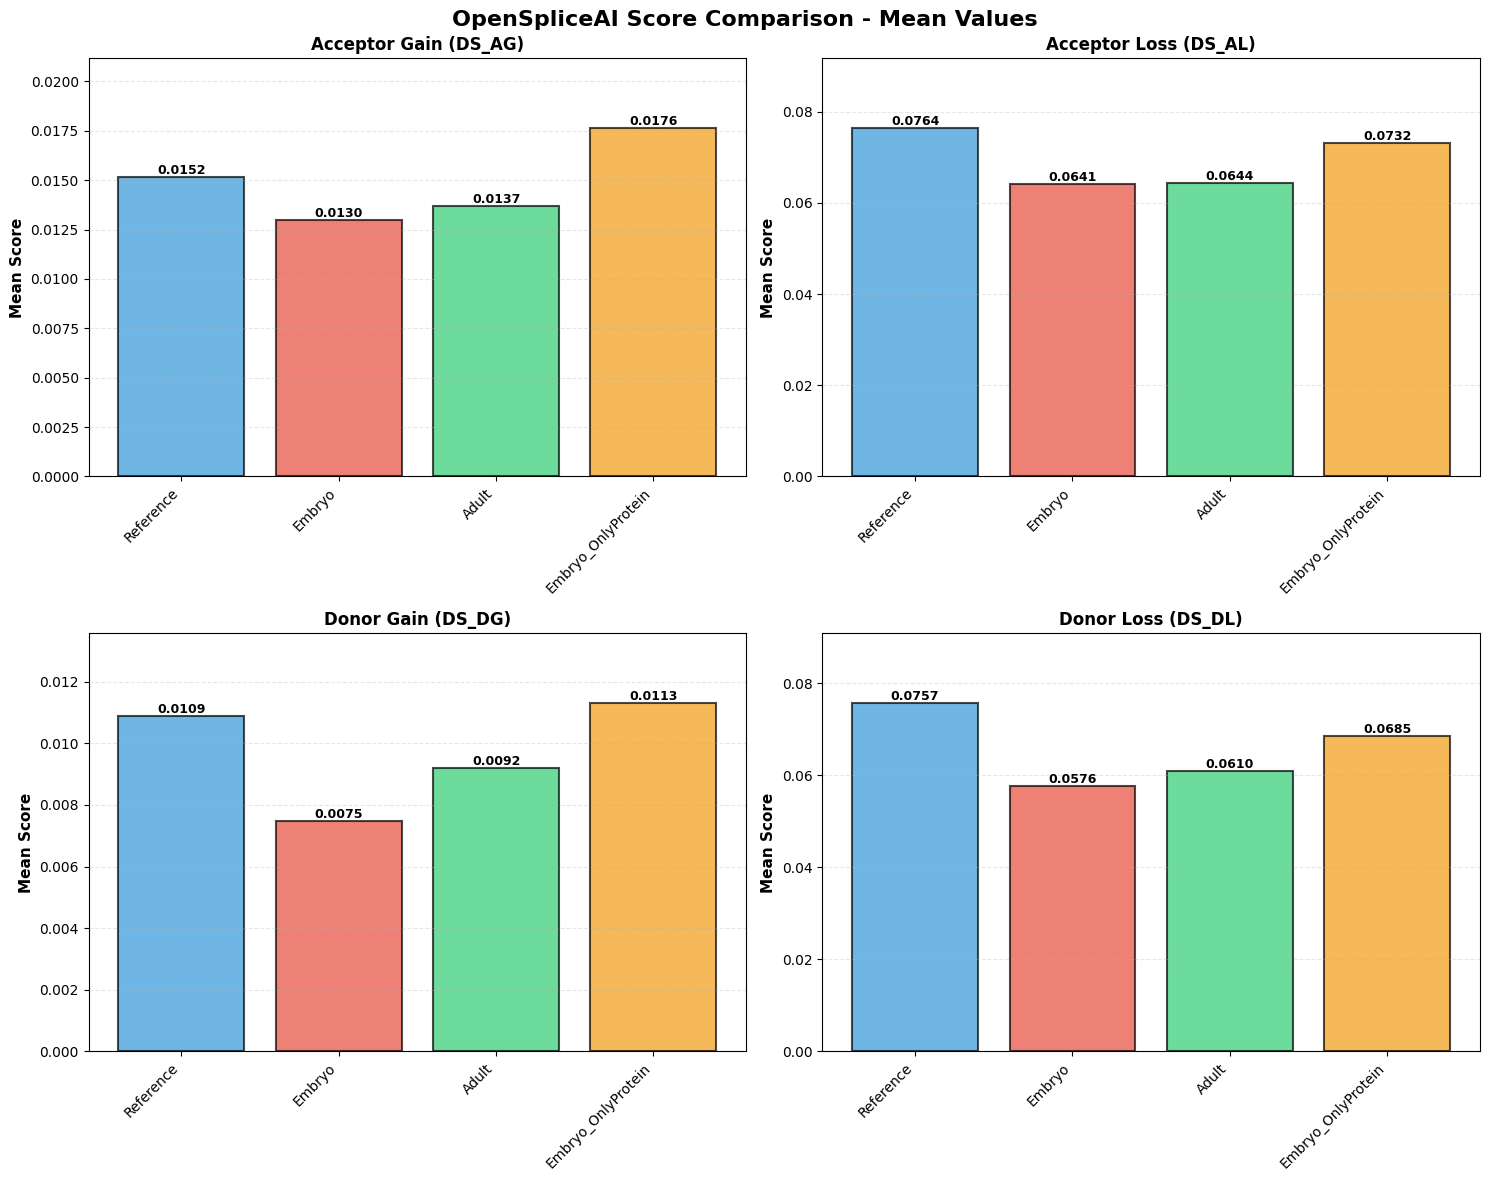

完整对比图已保存: all_scores_comparison.png

所有剪接类型的均值统计

DS_AG:
  Reference           : 0.015150
  Embryo              : 0.013004
  Adult               : 0.013712
  Embryo_OnlyProtein  : 0.017639

DS_AL:
  Reference           : 0.076438
  Embryo              : 0.064099
  Adult               : 0.064356
  Embryo_OnlyProtein  : 0.073176

DS_DG:
  Reference           : 0.010901
  Embryo              : 0.007489
  Adult               : 0.009185
  Embryo_OnlyProtein  : 0.011309

DS_DL:
  Reference           : 0.075665
  Embryo              : 0.057639
  Adult               : 0.061009
  Embryo_OnlyProtein  : 0.068476


In [55]:
import matplotlib.pyplot as plt
import numpy as np

# 计算所有剪接类型的均值
score_types = ['DS_AG', 'DS_AL', 'DS_DG', 'DS_DL']
score_names = ['Acceptor Gain', 'Acceptor Loss', 'Donor Gain', 'Donor Loss']
models = ['reference', 'embryo', 'adult', 'embryo_onlyprotein']
model_labels = ['Reference', 'Embryo', 'Adult', 'Embryo_OnlyProtein']

# 创建2x2子图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('OpenSpliceAI Score Comparison - Mean Values', fontsize=16, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (score_type, score_name) in enumerate(zip(score_types, score_names)):
    ax = axes[idx // 2, idx % 2]
    
    # 计算每个模型的均值
    means = []
    for model in models:
        col_name = f'{model}_{score_type}'
        if col_name in comparison_df_stop.columns:
            means.append(comparison_df_stop[col_name].mean())
        else:
            means.append(0)
    
    # 画柱状图
    bars = ax.bar(model_labels, means, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # 在柱子上显示数值
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 美化
    ax.set_ylabel('Mean Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{score_name} ({score_type})', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(means) * 1.2 if max(means) > 0 else 0.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticklabels(model_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('all_scores_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("完整对比图已保存: all_scores_comparison.png")

# 打印统计表
print("\n" + "="*70)
print("所有剪接类型的均值统计")
print("="*70)
for score_type in score_types:
    print(f"\n{score_type}:")
    for model, label in zip(models, model_labels):
        col_name = f'{model}_{score_type}'
        if col_name in comparison_df_stop.columns:
            mean_val = comparison_df_stop[col_name].mean()
            print(f"  {label:20s}: {mean_val:.6f}")

In [27]:
models = ['reference', 'embryo', 'adult', 'embryo_onlyprotein']
score_types = ['DS_AG', 'DS_AL', 'DS_DG', 'DS_DL']

# 生成所有列名
all_score_cols = [f'{model}_{score}' for model in models for score in score_types]

# 筛选:只要任何一列 > 0.1
filtered_df = comparison_df[
    comparison_df[all_score_cols].gt(0.1).any(axis=1)
]

In [28]:
filtered_df 

,variant_id,CHROM,POS,REF,ALT,GENE,CONSEQUENCE,reference_DS_AG,reference_DS_AL,reference_DS_DG,...,embryo_DS_DG,embryo_DS_DL,adult_DS_AG,adult_DS_AL,adult_DS_DG,adult_DS_DL,embryo_onlyprotein_DS_AG,embryo_onlyprotein_DS_AL,embryo_onlyprotein_DS_DG,embryo_onlyprotein_DS_DL
0,10:100297470:C>A,10,100297470,C,A,PKD2L1,stop_gained_Likely_LOF,0.00,0.00,0.00,...,0.00,0.35,0.00,0.01,0.00,0.32,0.00,0.01,0.00,0.85
2,10:101037205:T>C,10,101037205,T,C,SFXN3,splice_donor_variant_Likely_LOF,0.00,0.00,0.82,...,0.49,0.86,0.00,0.00,0.44,0.93,0.00,0.00,0.62,0.96
7,10:102109082:TG>T,10,102109082,TG,T,LDB1,frameshift_variant_Likely_LOF,0.01,0.00,0.12,...,0.04,0.00,0.02,0.00,0.01,0.01,0.00,0.01,0.11,0.00
10,10:102162244:A>G,10,102162244,A,G,NOLC1,missense_variant_Protein_Changing,0.00,0.00,0.39,...,0.19,0.00,0.00,0.00,0.49,0.00,0.00,0.00,0.35,0.00
12,10:102812643:G>A,10,102812643,G,A,WBP1L,missense_variant_Protein_Changing,0.13,0.37,0.00,...,0.00,0.00,0.05,0.21,0.00,0.00,0.01,0.03,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4855,X:66599859:TC>T,X,66599859,TC,T,EDA2R,frameshift_variant_Likely_LOF,0.16,0.41,0.00,...,0.00,0.04,0.01,0.10,0.00,0.00,0.12,0.30,0.00,0.03
4856,X:68717435:T>A,X,68717435,T,A,STARD8,stop_gained_Likely_LOF,0.06,0.00,0.00,...,0.00,0.00,0.18,0.02,0.00,0.00,0.03,0.00,0.00,0.00
4861,X:71246099:C>A,X,71246099,C,A,ZMYM3,splice_acceptor_variant_Likely_LOF,0.90,0.96,0.00,...,0.00,0.00,0.86,0.79,0.00,0.00,0.73,0.94,0.00,0.00
4864,X:72181830:T>C,X,72181830,T,C,PIN4,splice_donor_variant_Likely_LOF,0.00,0.00,0.45,...,0.45,0.85,0.00,0.00,0.75,0.93,0.00,0.00,0.16,0.91


/tmp/ipykernel_2233483/2062268225.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_2233483/2062268225.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_2233483/2062268225.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')
/tmp/ipykernel_2233483/2062268225.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_labels, rotation=45, ha='right')


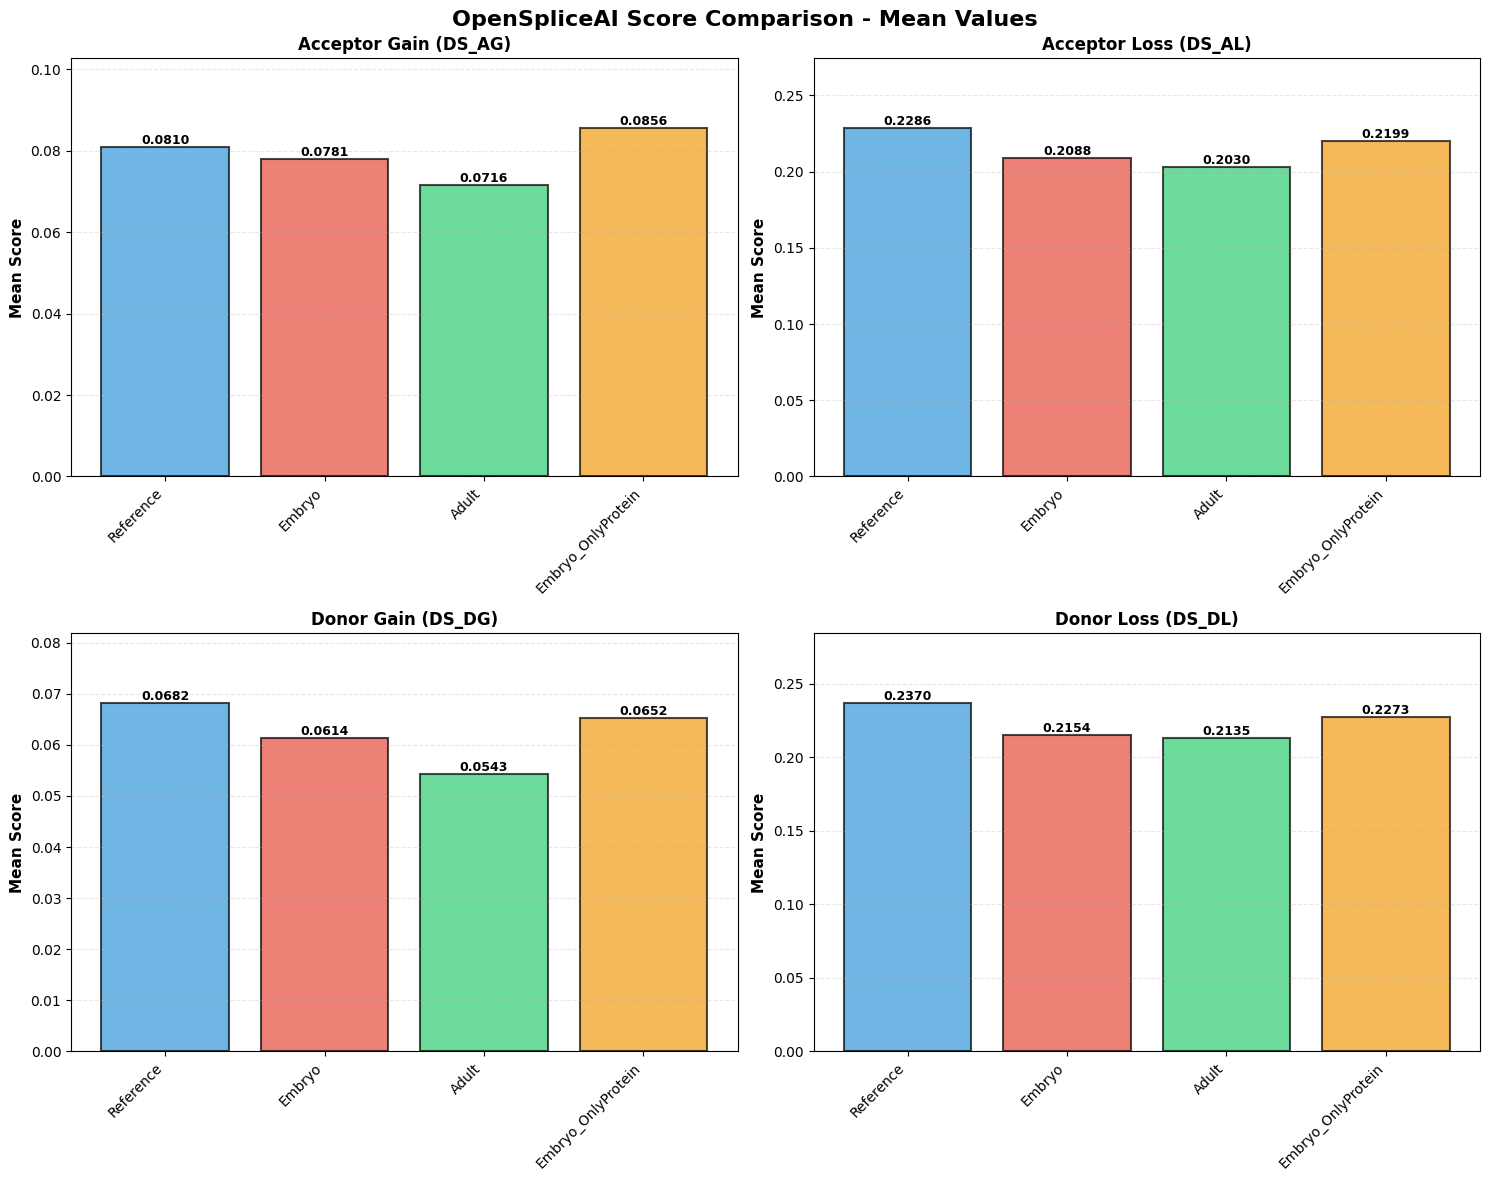

完整对比图已保存: all_scores_comparison.png

所有剪接类型的均值统计

DS_AG:
  Reference           : 0.081017
  Embryo              : 0.078057
  Adult               : 0.071554
  Embryo_OnlyProtein  : 0.085600

DS_AL:
  Reference           : 0.228594
  Embryo              : 0.208766
  Adult               : 0.202960
  Embryo_OnlyProtein  : 0.219851

DS_DG:
  Reference           : 0.068171
  Embryo              : 0.061383
  Adult               : 0.054251
  Embryo_OnlyProtein  : 0.065223

DS_DL:
  Reference           : 0.236983
  Embryo              : 0.215440
  Adult               : 0.213486
  Embryo_OnlyProtein  : 0.227337


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 计算所有剪接类型的均值
score_types = ['DS_AG', 'DS_AL', 'DS_DG', 'DS_DL']
score_names = ['Acceptor Gain', 'Acceptor Loss', 'Donor Gain', 'Donor Loss']
models = ['reference', 'embryo', 'adult', 'embryo_onlyprotein']
model_labels = ['Reference', 'Embryo', 'Adult', 'Embryo_OnlyProtein']

# 创建2x2子图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('OpenSpliceAI Score Comparison - Mean Values', fontsize=16, fontweight='bold')

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (score_type, score_name) in enumerate(zip(score_types, score_names)):
    ax = axes[idx // 2, idx % 2]
    
    # 计算每个模型的均值
    means = []
    for model in models:
        col_name = f'{model}_{score_type}'
        if col_name in filtered_df.columns:
            means.append(filtered_df[col_name].mean())
        else:
            means.append(0)
    
    # 画柱状图
    bars = ax.bar(model_labels, means, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # 在柱子上显示数值
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 美化
    ax.set_ylabel('Mean Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{score_name} ({score_type})', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(means) * 1.2 if max(means) > 0 else 0.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticklabels(model_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('all_scores_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("完整对比图已保存: all_scores_comparison.png")

# 打印统计表
print("\n" + "="*70)
print("所有剪接类型的均值统计")
print("="*70)
for score_type in score_types:
    print(f"\n{score_type}:")
    for model, label in zip(models, model_labels):
        col_name = f'{model}_{score_type}'
        if col_name in filtered_df.columns:
            mean_val = filtered_df[col_name].mean()
            print(f"  {label:20s}: {mean_val:.6f}")

In [30]:
filtered_df

,variant_id,CHROM,POS,REF,ALT,GENE,CONSEQUENCE,reference_DS_AG,reference_DS_AL,reference_DS_DG,...,embryo_DS_DG,embryo_DS_DL,adult_DS_AG,adult_DS_AL,adult_DS_DG,adult_DS_DL,embryo_onlyprotein_DS_AG,embryo_onlyprotein_DS_AL,embryo_onlyprotein_DS_DG,embryo_onlyprotein_DS_DL
0,10:100297470:C>A,10,100297470,C,A,PKD2L1,stop_gained_Likely_LOF,0.00,0.00,0.00,...,0.00,0.35,0.00,0.01,0.00,0.32,0.00,0.01,0.00,0.85
2,10:101037205:T>C,10,101037205,T,C,SFXN3,splice_donor_variant_Likely_LOF,0.00,0.00,0.82,...,0.49,0.86,0.00,0.00,0.44,0.93,0.00,0.00,0.62,0.96
7,10:102109082:TG>T,10,102109082,TG,T,LDB1,frameshift_variant_Likely_LOF,0.01,0.00,0.12,...,0.04,0.00,0.02,0.00,0.01,0.01,0.00,0.01,0.11,0.00
10,10:102162244:A>G,10,102162244,A,G,NOLC1,missense_variant_Protein_Changing,0.00,0.00,0.39,...,0.19,0.00,0.00,0.00,0.49,0.00,0.00,0.00,0.35,0.00
12,10:102812643:G>A,10,102812643,G,A,WBP1L,missense_variant_Protein_Changing,0.13,0.37,0.00,...,0.00,0.00,0.05,0.21,0.00,0.00,0.01,0.03,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4855,X:66599859:TC>T,X,66599859,TC,T,EDA2R,frameshift_variant_Likely_LOF,0.16,0.41,0.00,...,0.00,0.04,0.01,0.10,0.00,0.00,0.12,0.30,0.00,0.03
4856,X:68717435:T>A,X,68717435,T,A,STARD8,stop_gained_Likely_LOF,0.06,0.00,0.00,...,0.00,0.00,0.18,0.02,0.00,0.00,0.03,0.00,0.00,0.00
4861,X:71246099:C>A,X,71246099,C,A,ZMYM3,splice_acceptor_variant_Likely_LOF,0.90,0.96,0.00,...,0.00,0.00,0.86,0.79,0.00,0.00,0.73,0.94,0.00,0.00
4864,X:72181830:T>C,X,72181830,T,C,PIN4,splice_donor_variant_Likely_LOF,0.00,0.00,0.45,...,0.45,0.85,0.00,0.00,0.75,0.93,0.00,0.00,0.16,0.91


In [31]:
# 计算max_DS
for name in vcf_files.keys():
    cols = [f'{name}_DS_{t}' for t in ['AG', 'AL', 'DG', 'DL']]
    comparison_df[f'{name}_max_DS'] = comparison_df[cols].max(axis=1)

# 计算差异
for name in ['embryo', 'adult', 'embryo_onlyprotein']:
    for st in ['DS_AG', 'DS_AL', 'DS_DG', 'DS_DL']:
        comparison_df[f'{name}_vs_ref_{st}'] = comparison_df[f'{name}_{st}'] - comparison_df[f'reference_{st}']
    diff_cols = [f'{name}_vs_ref_DS_{t}' for t in ['AG', 'AL', 'DG', 'DL']]
    comparison_df[f'{name}_max_abs_diff'] = comparison_df[diff_cols].abs().max(axis=1)

print('计算完成!')
comparison_df.head(10)

计算完成!


,variant_id,CHROM,POS,REF,ALT,GENE,CONSEQUENCE,reference_DS_AG,reference_DS_AL,reference_DS_DG,...,adult_vs_ref_DS_AG,adult_vs_ref_DS_AL,adult_vs_ref_DS_DG,adult_vs_ref_DS_DL,adult_max_abs_diff,embryo_onlyprotein_vs_ref_DS_AG,embryo_onlyprotein_vs_ref_DS_AL,embryo_onlyprotein_vs_ref_DS_DG,embryo_onlyprotein_vs_ref_DS_DL,embryo_onlyprotein_max_abs_diff
0,10:100297470:C>A,10,100297470,C,A,PKD2L1,stop_gained_Likely_LOF,0.00,0.00,0.00,...,0.00,0.01,0.00,-0.16,0.16,0.00,0.01,0.00,0.37,0.37
1,10:100329234:ACAATATATAC>A,10,100329234,ACAATATATAC,A,PKD2L1,frameshift_variant_Likely_LOF,0.00,0.01,0.00,...,0.00,-0.01,0.00,0.01,0.01,0.00,0.01,0.00,0.02,0.02
2,10:101037205:T>C,10,101037205,T,C,SFXN3,splice_donor_variant_Likely_LOF,0.00,0.00,0.82,...,0.00,0.00,-0.38,-0.04,0.38,0.00,0.00,-0.20,-0.01,0.20
3,10:101535454:C>T,10,101535454,C,T,BTRC,missense_variant_Protein_Changing,0.00,0.00,0.00,...,0.00,0.00,0.00,0.02,0.02,0.00,0.00,0.00,0.01,0.01
4,10:101579652:G>A,10,101579652,G,A,POLL,missense_variant_Protein_Changing,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,10:101847536:T>C,10,101847536,T,C,ARMH3,missense_variant_Protein_Changing,0.00,0.01,0.00,...,0.00,-0.01,0.00,0.00,0.01,0.00,-0.01,0.00,0.00,0.01
6,10:102108254:T>G,10,102108254,T,G,LDB1,missense_variant_Protein_Changing,0.00,0.01,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,-0.01,0.00,0.00,0.01
7,10:102109082:TG>T,10,102109082,TG,T,LDB1,frameshift_variant_Likely_LOF,0.01,0.00,0.12,...,0.01,0.00,-0.11,0.01,0.11,-0.01,0.01,-0.01,0.00,0.01
8,10:102139970:A>G,10,102139970,A,G,PPRC1,missense_variant_Protein_Changing,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
9,10:102160494:C>G,10,102160494,C,G,NOLC1,missense_variant_Protein_Changing,0.00,0.00,0.00,...,0.00,0.01,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00


In [33]:
print('='*60)
print('基本统计')
print('='*60)
for name in vcf_files.keys():
    col = f'{name}_max_DS'
    high = (comparison_df[col] > 0.1).sum()
    mid = ((comparison_df[col] > 0.2) & (comparison_df[col] <= 0.5)).sum()
    low = ((comparison_df[col] > 0.1) & (comparison_df[col] <= 0.2)).sum()
    print(f'\n{name}:')
    print(f'  高分(>0.1): {high}')
    print(f'  中分(0.2-0.5): {mid}')
    print(f'  低分(<0.2): {low}')

基本统计

reference:
  高分(>0.1): 615
  中分(0.2-0.5): 170
  低分(<0.2): 141

embryo:
  高分(>0.1): 580
  中分(0.2-0.5): 142
  低分(<0.2): 152

adult:
  高分(>0.1): 624
  中分(0.2-0.5): 170
  低分(<0.2): 178

embryo_onlyprotein:
  高分(>0.1): 600
  中分(0.2-0.5): 171
  低分(<0.2): 130
